<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-311/blob/main/Case_Study_3_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [54]:
df = pd.read_csv('/content/philippine_fuel_prices_2023.csv', parse_dates=['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             52 non-null     datetime64[ns]
 1   Diesel_PHP       52 non-null     float64       
 2   Unleaded_91_PHP  52 non-null     float64       
 3   Premium_95_PHP   52 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.8 KB


In [55]:
df['Month'] = df['Date'].dt.month_name()
df['Week_Number'] = df['Date'].dt.isocalendar().week

In [56]:
df_melted = df.melt(
    id_vars=['Date', 'Month', 'Week_Number'],
    value_vars=['Diesel_PHP', 'Unleaded_91_PHP', 'Premium_95_PHP'],
    var_name='Fuel_Type',
    value_name='Price_PHP'
)

In [50]:
df_melted['Fuel_Type'] = df_melted['Fuel_Type'].str.replace('_PHP', '').str.replace('_', ' ')

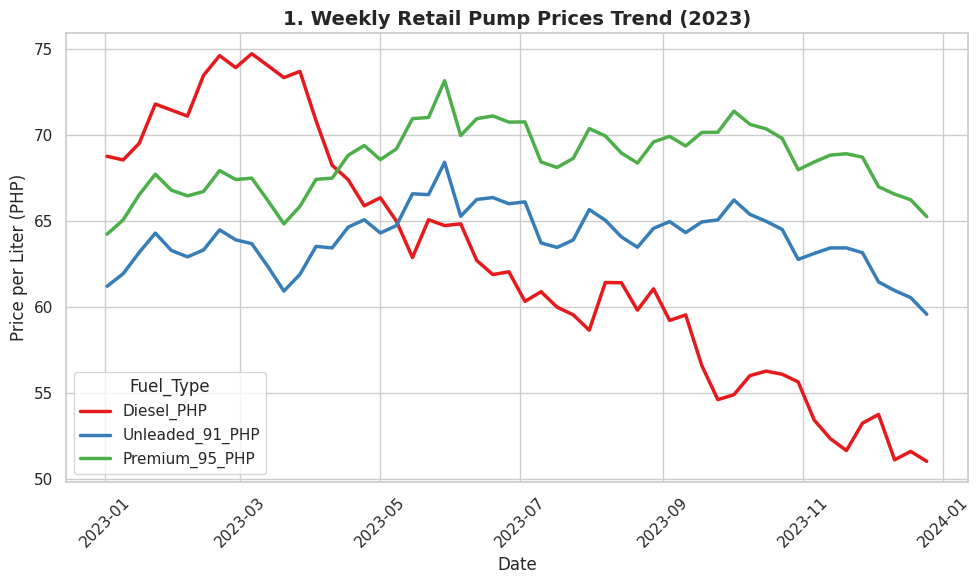

In [60]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=df_melted, x='Date', y='Price_PHP', hue='Fuel_Type', linewidth=2.5, palette='Set1')

plt.title('1. Weekly Retail Pump Prices Trend (2023)', fontsize=14, fontweight='bold')
plt.ylabel('Price per Liter (PHP)')
plt.xlabel('Date')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

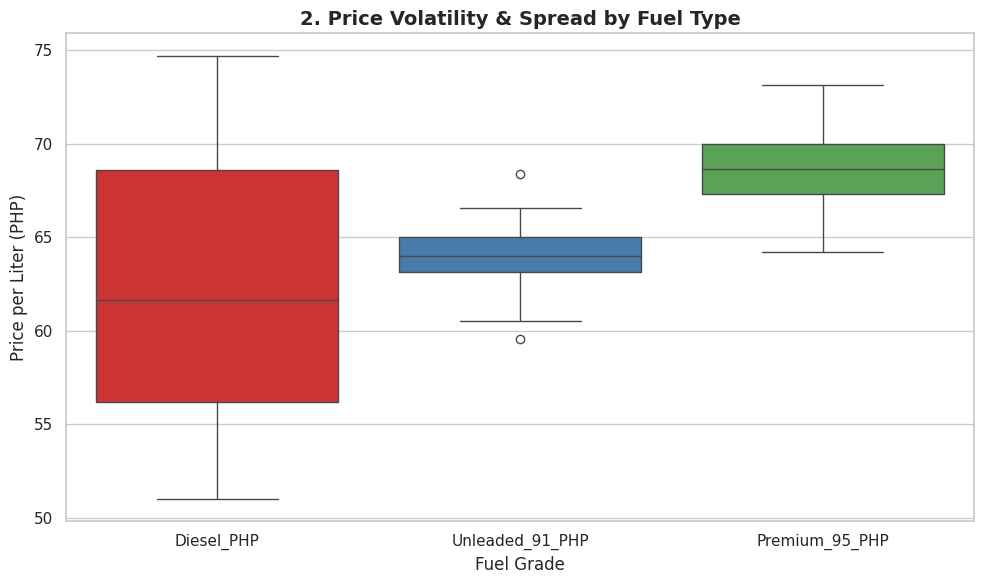

In [63]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_melted, x='Fuel_Type', y='Price_PHP', hue='Fuel_Type', palette='Set1', legend=False)

plt.title('2. Price Volatility & Spread by Fuel Type', fontsize=14, fontweight='bold')
plt.ylabel('Price per Liter (PHP)')
plt.xlabel('Fuel Grade')

plt.tight_layout()
plt.show()

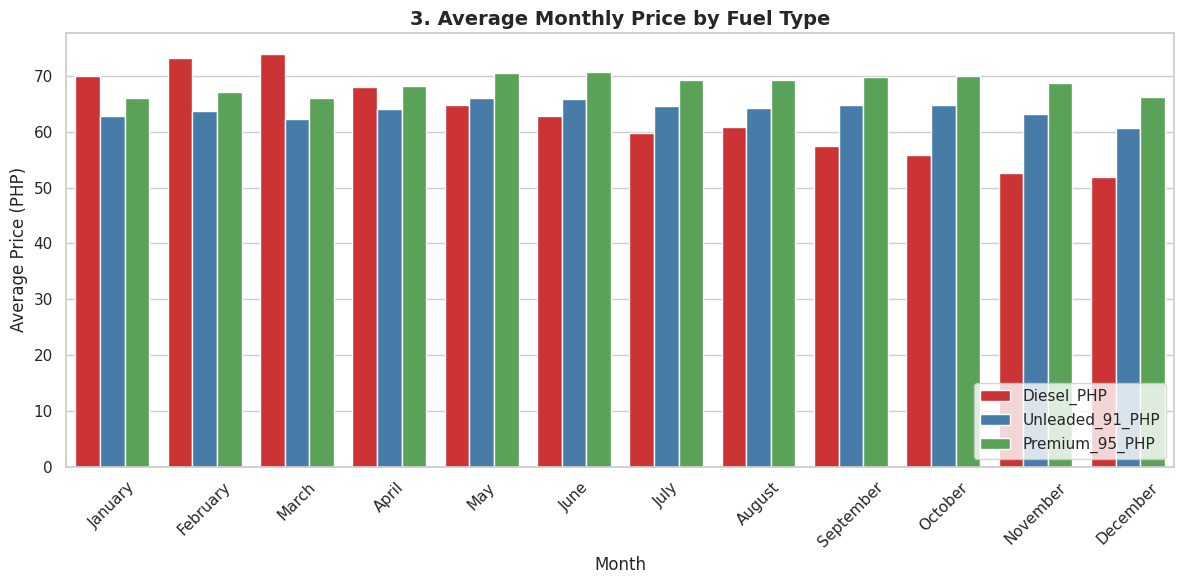

In [64]:

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df_melted['Month'] = pd.Categorical(df_melted['Month'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 6))


sns.barplot(data=df_melted, x='Month', y='Price_PHP', hue='Fuel_Type', palette='Set1', errorbar=None)

plt.title('3. Average Monthly Price by Fuel Type', fontsize=14, fontweight='bold')
plt.ylabel('Average Price (PHP)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

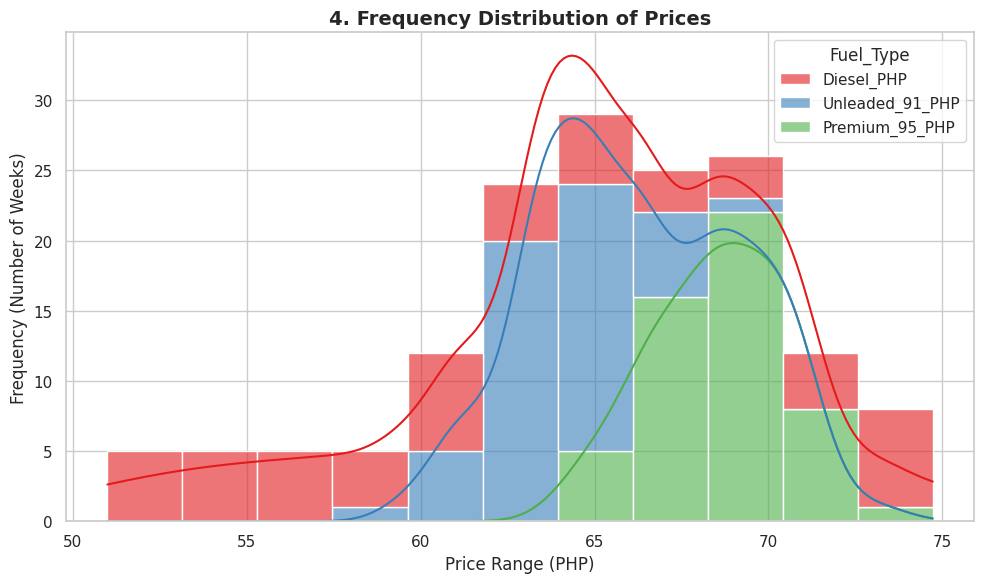

In [66]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df_melted, x='Price_PHP', hue='Fuel_Type', palette='Set1', kde=True, multiple="stack", alpha=0.6)

plt.title('4. Frequency Distribution of Prices', fontsize=14, fontweight='bold')
plt.ylabel('Frequency (Number of Weeks)')
plt.xlabel('Price Range (PHP)')

plt.tight_layout()
plt.show()